<a href="https://colab.research.google.com/github/Karidan/Intellectual-Data-Analysis-2025/blob/main/Lab4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.19.0
Зображення завантажено.
Початок перенесення стилю...
....................................................................................................
Епоха 1/10 завершена.
....................................................................................................
Епоха 2/10 завершена.
....................................................................................................
Епоха 3/10 завершена.
....................................................................................................
Епоха 4/10 завершена.
....................................................................................................
Епоха 5/10 завершена.
....................................................................................................
Епоха 6/10 завершена.
....................................................................................................
Епоха 7/10 завершена.
...........................................................

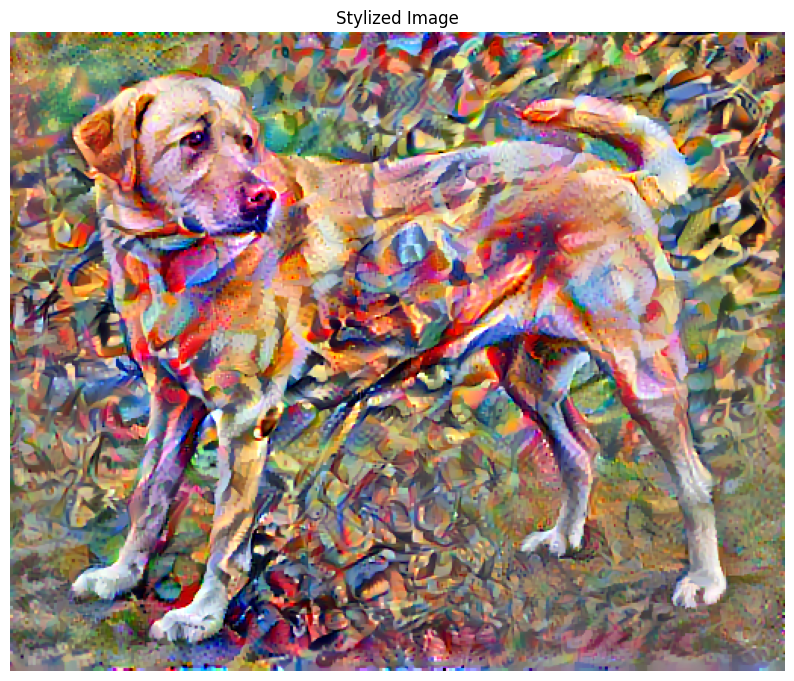

In [7]:
import tensorflow as tf
import numpy as np
import PIL.Image
import time
import functools
import matplotlib.pyplot as plt

# Налаштування для відображення прогресу
print(f"TensorFlow Version: {tf.__version__}")

def tensor_to_image(tensor):
    """Перетворює тензор назад у зображення для збереження."""
    tensor = tensor * 255
    tensor = np.array(tensor, dtype=np.uint8)
    if np.ndim(tensor) > 3:
        assert tensor.shape[0] == 1
        tensor = tensor[0]
    return PIL.Image.fromarray(tensor)

def imshow(image, title=None):
    """Відображає тензор як зображення за допомогою Matplotlib."""
    if len(image.shape) > 3:
        image = tf.squeeze(image, axis=0)

    plt.imshow(image)
    if title:
        plt.title(title)

def load_img(path_to_img):
    """Завантажує зображення та обмежує його розмір до 512 пікселів."""
    max_dim = 512
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img

def vgg_layers(layer_names):
    """Створює модель VGG19, яка повертає список проміжних вихідних значень."""
    # Завантажуємо VGG19, попередньо навчену на ImageNet
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False

    outputs = [vgg.get_layer(name).output for name in layer_names]
    model = tf.keras.Model([vgg.input], outputs)
    return model

def gram_matrix(input_tensor):
    """Розрахунок матриці Грама для визначення стилю."""
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result / num_locations

class StyleContentModel(tf.keras.models.Model):
    """Модель для розрахунку виходів стилю та контенту."""
    def __init__(self, style_layers, content_layers):
        super(StyleContentModel, self).__init__()
        self.vgg = vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False

    def call(self, inputs):
        """Прохід через мережу."""
        inputs = inputs * 255.0
        # Препроцесинг, необхідний для VGG19
        preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
        outputs = self.vgg(preprocessed_input)

        style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                          outputs[self.num_style_layers:])

        style_outputs = [gram_matrix(style_output)
                         for style_output in style_outputs]

        content_dict = {content_name: value
                        for content_name, value
                        in zip(self.content_layers, content_outputs)}

        style_dict = {style_name: value
                      for style_name, value
                      in zip(self.style_layers, style_outputs)}

        return {'content': content_dict, 'style': style_dict}

def clip_0_1(image):
    """Обрізає значення пікселів, щоб вони залишалися в межах [0, 1]."""
    return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

def style_content_loss(outputs, style_targets, content_targets, style_weight, content_weight):
    """Функція втрат (Loss Function)."""
    style_outputs = outputs['style']
    content_outputs = outputs['content']

    style_loss = tf.add_n([tf.reduce_mean((style_outputs[name]-style_targets[name])**2)
                           for name in style_outputs.keys()])
    style_loss *= style_weight / num_style_layers

    content_loss = tf.add_n([tf.reduce_mean((content_outputs[name]-content_targets[name])**2)
                             for name in content_outputs.keys()])
    content_loss *= content_weight / num_content_layers

    loss = style_loss + content_loss
    return loss

# --- ГОЛОВНА ЧАСТИНА ПРОГРАМИ ---

# 1. Завантаження зображень (використовуємо приклади з інтернету)
# Ви можете замінити ці посилання на локальні шляхи до файлів (наприклад, 'my_photo.jpg')
content_path = tf.keras.utils.get_file('YellowLabradorLooking_new.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')
style_path = tf.keras.utils.get_file('kandinsky5.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

content_image = load_img(content_path)
style_image = load_img(style_path)

print("Зображення завантажено.")

# 2. Визначення шарів для аналізу
content_layers = ['block5_conv2']
style_layers = ['block1_conv1',
                'block2_conv1',
                'block3_conv1',
                'block4_conv1',
                'block5_conv1']

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

# 3. Ініціалізація моделі
extractor = StyleContentModel(style_layers, content_layers)

# 4. Розрахунок цільових значень (те, до чого ми прагнемо)
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

# 5. Створення змінної зображення, яке ми будемо оптимізувати
image = tf.Variable(content_image)

# 6. Налаштування оптимізатора
opt = tf.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

style_weight = 1e-2
content_weight = 1e4

# 7. Крок навчання
@tf.function()
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = extractor(image)
        loss = style_content_loss(outputs, style_targets, content_targets, style_weight, content_weight)

        # Додаємо total variation loss для згладжування (зменшення шуму)
        loss += tf.image.total_variation(image) * 30

    grad = tape.gradient(loss, image)
    opt.apply_gradients([(grad, image)])
    image.assign(clip_0_1(image))

# 8. Запуск циклу навчання
import time
start = time.time()

epochs = 10
steps_per_epoch = 100

print("Початок перенесення стилю...")

step = 0
for n in range(epochs):
    for m in range(steps_per_epoch):
        step += 1
        train_step(image)
        print(f".", end='', flush=True)

    print(f"\nЕпоха {n+1}/{epochs} завершена.")

    # Збереження проміжного результату (опціонально)
    # tensor_to_image(image).save(f"stylized_epoch_{n+1}.png")

end = time.time()
print(f"\nГотово! Час виконання: {end-start:.1f} сек")

# 9. Збереження фінального результату
file_name = 'stylized-image.png'
tensor_to_image(image).save(file_name)

print(f"Зображення збережено як {file_name}")

# Відображення результату на екрані
plt.figure(figsize=(10, 10))
imshow(image, 'Stylized Image')
plt.axis('off') # Прибрати осі координат
plt.show()

Результати

В результаті роботи програми було згенеровано зображення, яке зберігає семантичний зміст вхідної фотографії (силует та риси собаки), але візуалізує його в художній манері обраної картини (стиль Кандинського).

Ключові спостереження:

Баланс ваг: Критичним етапом є налаштування співвідношення style_weight (1e-2) та content_weight (1e4). Зміна цих параметрів дозволяє регулювати ступінь абстракції фінального зображення.

Час виконання: Алгоритм є обчислювально затратним, оскільки кожна ітерація вимагає повного прямого та зворотного проходу через глибоку нейронну мережу.

Total Variation Loss: Додавання регуляризації (total variation) виявилося важливим для зменшення високочастотного шуму та отримання більш гладкого та візуально приємного зображення.

Висновок

Лабораторна робота продемонструвала ефективність використання ознак (feature maps) глибоких нейронних мереж для задач комп'ютерного зору, що виходять за межі класифікації. Метод NST підтверджує, що згорткові мережі здатні успішно декомпозувати зображення на стиль та зміст, що відкриває широкі можливості для генеративного мистецтва та обробки зображень.